# QC for Features

In [1]:
########################################## DEFINE SESSION ##########################################
session = '2025_10_17_14_45_34_trial_1_TP_regions_125_454_383_1391'
final = False
####################################################################################################

import numpy as np
import csv
import re
from matplotlib import pyplot as plt

####################################################################################
####################################################################################
base_path = '/n/holylabs/gershman_lab/Users/zkelso/Features/'
if final == True:
    features_path = base_path + session + '_fullvideo_frame_split_FINAL_points_Feature_vector.npy'
else:
    features_path = base_path + session + '_fullvideo_frame_split_0_1799_points_Feature_vector.npy'

data = np.load(features_path)   # or allow_pickle=True if needed
csv_path = "/n/holylabs/gershman_lab/Users/zkelso/video_splits.csv"

print(features_path)

feat1 = base_path + session + '_fullvideo_frame_split_FINAL_points_Feature_vector.npy'
feat2 = base_path + session + '_fullvideo_frame_split_0_1799_points_Feature_vector.npy'
same = np.array_equal(feat1, feat2)
if same:
    print('SAME')
else:
    print('0...1799 and final are distinct')

FileNotFoundError: [Errno 2] No such file or directory: '/n/holylabs/gershman_lab/Users/zkelso/Features/2025_10_17_14_45_34_trial_1_TP_regions_125_454_383_1391_fullvideo_frame_split_0_1799_points_Feature_vector.npy'

In [2]:
def _parse_start_end_from_row(row):
    # Rejoin everything after the first column
    rest = ",".join(row[1:]).strip()
    # Find all [...] groups
    groups = re.findall(r"\[(.*?)\]", rest)
    starts, ends = [], []
    if len(groups) >= 1:
        starts = [int(x) for x in groups[0].split(",") if x.strip()]
    if len(groups) >= 2:
        ends   = [int(x) for x in groups[1].split(",") if x.strip()]
    return starts, ends

def get_session_splits(csv_path, session_name):
    with open(csv_path, newline="") as f:
        reader = csv.reader(f)
        for row in reader:
            if not row:
                continue
            date = row[0].strip()
            if date != session_name:
                continue
            return _parse_start_end_from_row(row)
    raise ValueError(f"Session {session_name!r} not found in CSV")

# --- Usage example ---

start_frames, end_frames = get_session_splits(csv_path, session)

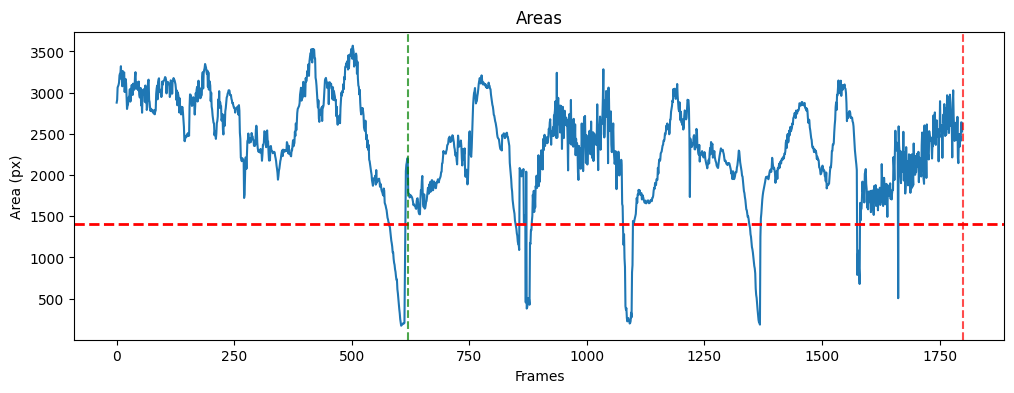

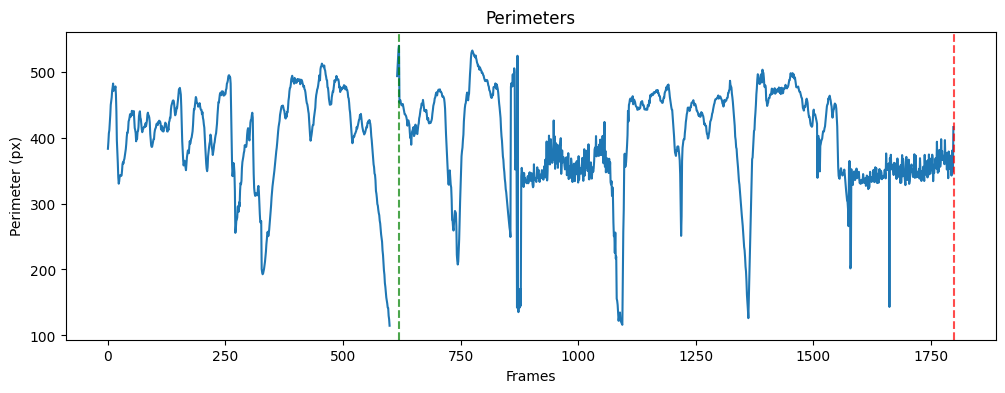

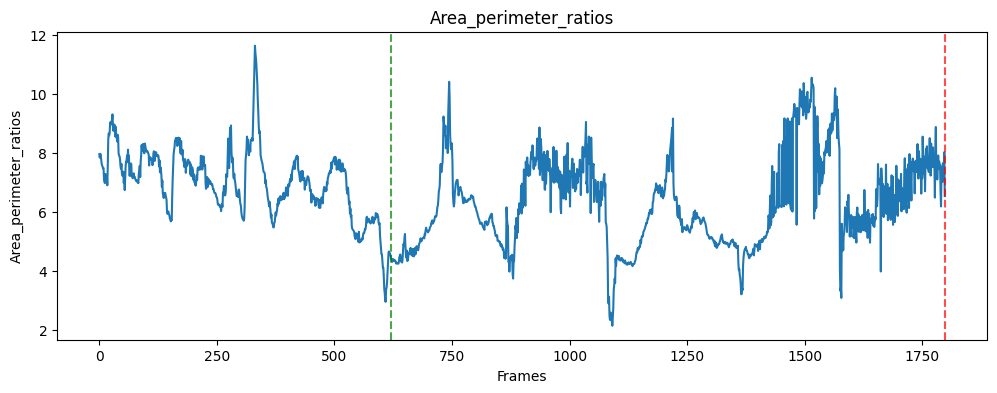

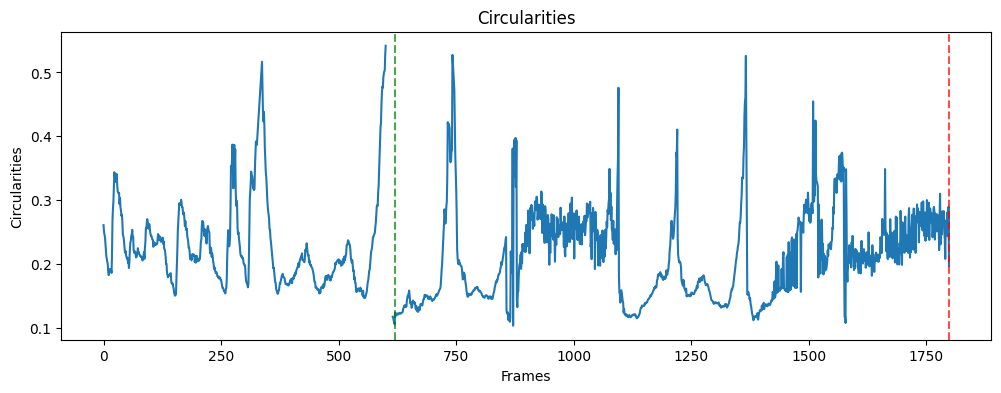

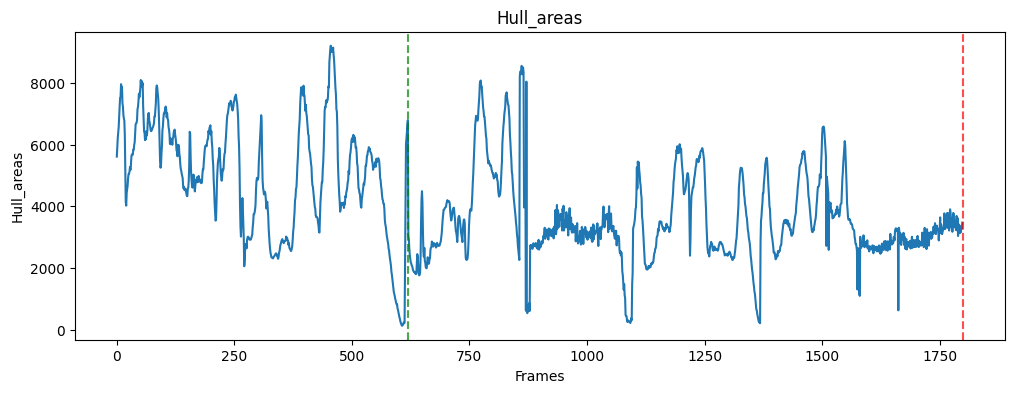

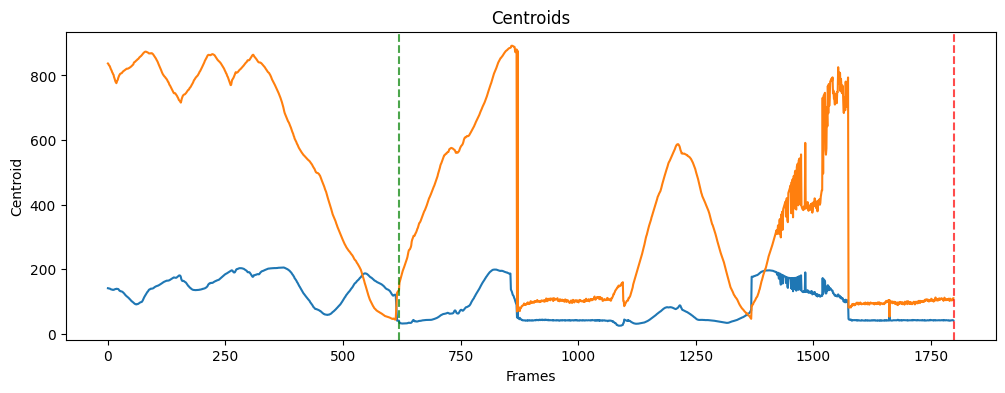

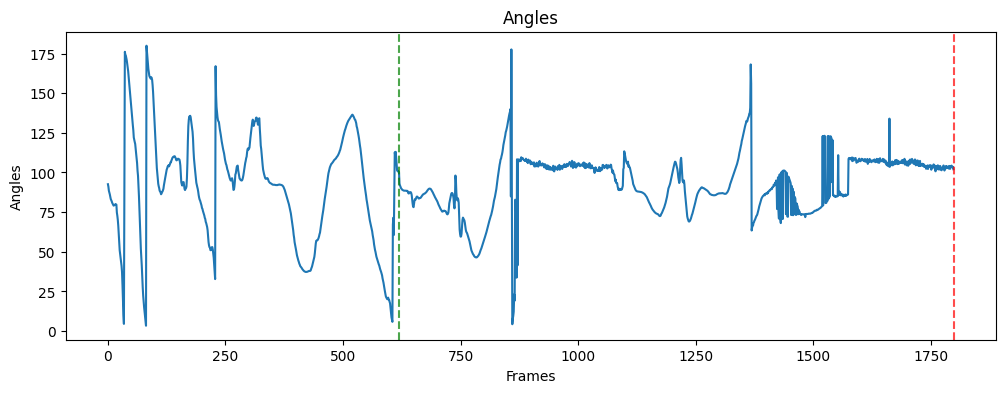

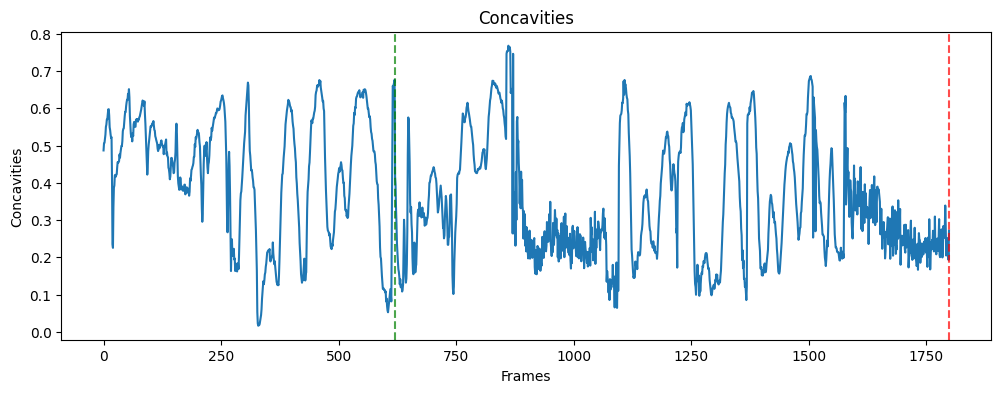

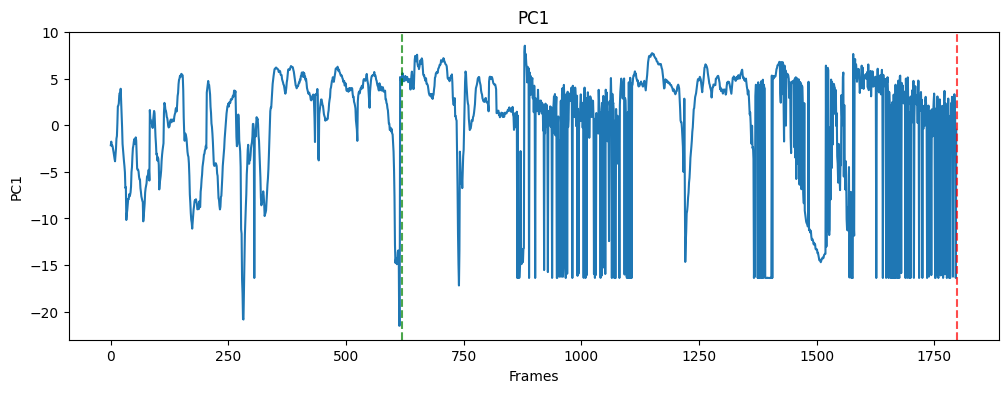

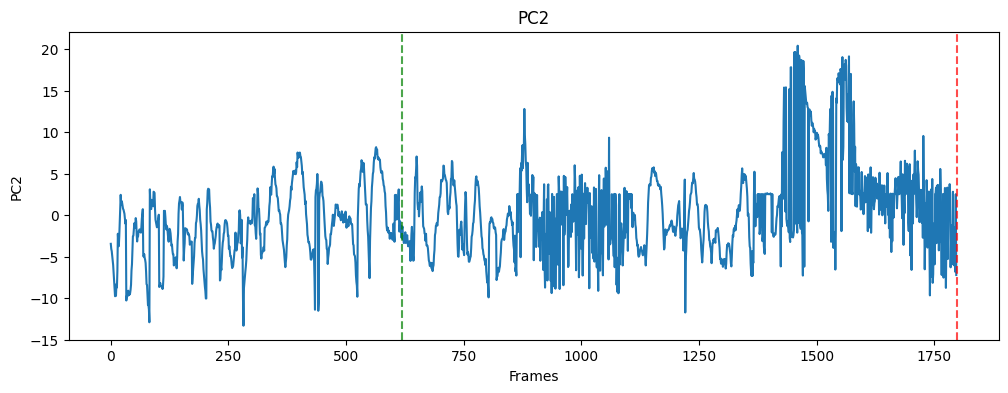

In [3]:
Areas = data[0,:]; Area_percentages = data[1,:]; Perimeters = data[2,:]; Area_perimeter_ratios = data[3,:]; Circularities = data[4,:]; Hull_areas = data[5,:]; Centroidxs= data[6,:];  Centroidys = data[7,:]; Angles= data[8,:]; Concavities = data[9,:]; PC1= data[10,:]; PC2 = data[11,:];

plt.figure(figsize=(12, 4))  # wider and shorter; change numbers to adjust ratio
plt.plot(Areas); plt.title('Areas'); plt.xlabel("Frames"); plt.ylabel("Area (px)"); 
plt.axhline(y=np.mean(Areas) - 1.5*np.std(Areas), color='r', linestyle='--', linewidth=2)
# Draw vertical lines
for s in start_frames:
    plt.axvline(x=s, color='g', linestyle='--', alpha=0.7, label='start' if s == start_frames[0] else None)
for e in end_frames:
    plt.axvline(x=e, color='r', linestyle='--', alpha=0.7, label='end' if e == end_frames[0] else None)
plt.show()

plt.figure(figsize=(12, 4))  # wider and shorter; change numbers to adjust ratio
plt.plot(Perimeters); plt.title('Perimeters'); plt.xlabel("Frames"); plt.ylabel("Perimeter (px)"); 
for s in start_frames:
    plt.axvline(x=s, color='g', linestyle='--', alpha=0.7, label='start' if s == start_frames[0] else None)
for e in end_frames:
    plt.axvline(x=e, color='r', linestyle='--', alpha=0.7, label='end' if e == end_frames[0] else None)
plt.show()

plt.figure(figsize=(12, 4))  # wider and shorter; change numbers to adjust ratio
plt.plot(Area_perimeter_ratios); plt.title('Area_perimeter_ratios'); plt.xlabel("Frames"); plt.ylabel("Area_perimeter_ratios"); 
for s in start_frames:
    plt.axvline(x=s, color='g', linestyle='--', alpha=0.7, label='start' if s == start_frames[0] else None)
for e in end_frames:
    plt.axvline(x=e, color='r', linestyle='--', alpha=0.7, label='end' if e == end_frames[0] else None)
plt.show()


plt.figure(figsize=(12, 4))  # wider and shorter; change numbers to adjust ratio
plt.plot(Circularities); plt.title('Circularities'); plt.xlabel("Frames"); plt.ylabel("Circularities"); 
for s in start_frames:
    plt.axvline(x=s, color='g', linestyle='--', alpha=0.7, label='start' if s == start_frames[0] else None)
for e in end_frames:
    plt.axvline(x=e, color='r', linestyle='--', alpha=0.7, label='end' if e == end_frames[0] else None)
plt.show()


plt.figure(figsize=(12, 4))  # wider and shorter; change numbers to adjust ratio
plt.plot(Hull_areas); plt.title('Hull_areas'); plt.xlabel("Frames"); plt.ylabel("Hull_areas"); 
for s in start_frames:
    plt.axvline(x=s, color='g', linestyle='--', alpha=0.7, label='start' if s == start_frames[0] else None)
for e in end_frames:
    plt.axvline(x=e, color='r', linestyle='--', alpha=0.7, label='end' if e == end_frames[0] else None)
plt.show()


plt.figure(figsize=(12, 4))  # wider and shorter; change numbers to adjust ratio
plt.plot(Centroidxs); plt.plot(Centroidys);  plt.title('Centroids'); plt.xlabel("Frames"); plt.ylabel("Centroid");  
for s in start_frames:
    plt.axvline(x=s, color='g', linestyle='--', alpha=0.7, label='start' if s == start_frames[0] else None)
for e in end_frames:
    plt.axvline(x=e, color='r', linestyle='--', alpha=0.7, label='end' if e == end_frames[0] else None)
plt.show()


plt.figure(figsize=(12, 4))  # wider and shorter; change numbers to adjust ratio
plt.plot(Angles); plt.title('Angles'); plt.xlabel("Frames"); plt.ylabel("Angles"); 
for s in start_frames:
    plt.axvline(x=s, color='g', linestyle='--', alpha=0.7, label='start' if s == start_frames[0] else None)
for e in end_frames:
    plt.axvline(x=e, color='r', linestyle='--', alpha=0.7, label='end' if e == end_frames[0] else None)
plt.show()


plt.figure(figsize=(12, 4))  # wider and shorter; change numbers to adjust ratio
plt.plot(Concavities); plt.title('Concavities'); plt.xlabel("Frames"); plt.ylabel("Concavities"); 
for s in start_frames:
    plt.axvline(x=s, color='g', linestyle='--', alpha=0.7, label='start' if s == start_frames[0] else None)
for e in end_frames:
    plt.axvline(x=e, color='r', linestyle='--', alpha=0.7, label='end' if e == end_frames[0] else None)
plt.show()


plt.figure(figsize=(12, 4))  # wider and shorter; change numbers to adjust ratio
plt.plot(PC1); plt.title('PC1'); plt.xlabel("Frames"); plt.ylabel("PC1"); 
for s in start_frames:
    plt.axvline(x=s, color='g', linestyle='--', alpha=0.7, label='start' if s == start_frames[0] else None)
for e in end_frames:
    plt.axvline(x=e, color='r', linestyle='--', alpha=0.7, label='end' if e == end_frames[0] else None)
plt.show()


plt.figure(figsize=(12, 4))  # wider and shorter; change numbers to adjust ratio
plt.plot(PC2); plt.title('PC2'); plt.xlabel("Frames"); plt.ylabel("PC2"); 
for s in start_frames:
    plt.axvline(x=s, color='g', linestyle='--', alpha=0.7, label='start' if s == start_frames[0] else None)
for e in end_frames:
    plt.axvline(x=e, color='r', linestyle='--', alpha=0.7, label='end' if e == end_frames[0] else None)
plt.show()


